# Assignment 4: LSTM-Based Time-Series Forecasting

## Problem Statement
Develop an LSTM (Long Short-Term Memory) based deep learning model for time-series forecasting using a stock price dataset.

## Objective
The objective of this assignment is to understand how recurrent neural networks, particularly LSTM, can learn patterns from historical time-series data and predict future stock prices.

## Dataset
For this assignment, historical stock price data will be obtained directly from **Yahoo Finance** using the `yfinance` Python library. No manual dataset download or Google Drive upload is required.

The dataset contains commonly used stock-market features such as:

- Date
- Open Price
- High Price
- Low Price
- Close Price
- Adjusted Close Price
- Trading Volume

We will primarily use the **Closing Price** for forecasting.

## Why LSTM?
Stock prices are sequential/time-dependent data, where previous observations can influence future observations. LSTM is a type of Recurrent Neural Network (RNN) designed to learn dependencies in sequential data and handle long-term patterns more effectively than a basic RNN.

## Main Steps

1. Import required Python libraries.
2. Collect historical stock data using `yfinance`.
3. Explore and visualize the dataset.
4. Select the required feature.
5. Preprocess and scale the data using `MinMaxScaler`.
6. Divide the data into training and testing sets.
7. Convert the time-series data into input sequences/windows.
8. Build an LSTM neural network.
9. Compile the model using Adam optimizer and Mean Squared Error (MSE) loss.
10. Train the LSTM model.
11. Generate predictions on the test data.
12. Convert predictions back to the original price scale.
13. Evaluate the model using MAE and RMSE.
14. Visualize actual prices against predicted prices.

## Expected Output
The assignment will produce:

- Historical stock-price visualizations
- Training and testing data
- LSTM model architecture
- Training/validation loss graph
- Predicted stock prices
- MAE and RMSE evaluation metrics
- Actual vs Predicted stock-price graph

## Technologies Used

- Python
- Google Colab
- NumPy
- Pandas
- Matplotlib
- Scikit-learn
- TensorFlow / Keras
- yfinance

## Learning Outcome
After completing this assignment, we will understand how LSTM networks can be applied to time-series forecasting, how sequential data is prepared for an LSTM model, how the model is trained, and how its forecasting performance is evaluated.

In [1]:
# Install yfinance for directly fetching stock market data
!pip -q install yfinance

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine Learning / Data Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# For downloading stock data
import yfinance as yf

# Check TensorFlow version
print("TensorFlow Version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow Version: 2.20.0
Libraries imported successfully!


In [3]:
# Download stock market dataset directly from GitHub
url = "https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv"

data = pd.read_csv(url)

# Convert Date column into datetime format
data["Date"] = pd.to_datetime(data["Date"])

# Sort data chronologically
data = data.sort_values("Date").reset_index(drop=True)

# Display dataset information
print("Dataset Shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

# Display first 5 rows
data.head()

Dataset Shape: (506, 11)

Columns:
['Date', 'AAPL.Open', 'AAPL.High', 'AAPL.Low', 'AAPL.Close', 'AAPL.Volume', 'AAPL.Adjusted', 'dn', 'mavg', 'up', 'direction']


,Date,AAPL.Open,AAPL.High,AAPL.Low,AAPL.Close,AAPL.Volume,AAPL.Adjusted,dn,mavg,up,direction
0,2015-02-17,127.489998,128.880005,126.919998,127.830002,63152400,122.905254,106.741052,117.927667,129.114281,Increasing
1,2015-02-18,127.629997,128.779999,127.449997,128.720001,44891700,123.760965,107.842423,118.940333,130.038244,Increasing
2,2015-02-19,128.479996,129.029999,128.330002,128.449997,37362400,123.501363,108.894245,119.889167,130.884089,Decreasing
3,2015-02-20,128.619995,129.500000,128.050003,129.500000,48948400,124.510914,109.785449,120.763500,131.741551,Increasing
4,2015-02-23,130.020004,133.000000,129.660004,133.000000,70974100,127.876074,110.372516,121.720167,133.067817,Increasing


In [4]:
# Display basic information about the dataset
print("Dataset Information:")
print("-" * 50)
data.info()

print("\nMissing Values:")
print("-" * 50)
print(data.isnull().sum())

print("\nStatistical Summary:")
print("-" * 50)
data.describe()

Dataset Information:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           506 non-null    datetime64[ns]
 1   AAPL.Open      506 non-null    float64       
 2   AAPL.High      506 non-null    float64       
 3   AAPL.Low       506 non-null    float64       
 4   AAPL.Close     506 non-null    float64       
 5   AAPL.Volume    506 non-null    int64         
 6   AAPL.Adjusted  506 non-null    float64       
 7   dn             506 non-null    float64       
 8   mavg           506 non-null    float64       
 9   up             506 non-null    float64       
 10  direction      506 non-null    object        
dtypes: datetime64[ns](1), float64(8), int64(1), object(1)
memory usage: 43.6+ KB

Missing Values:
--------------------------------------------------
Date      

,Date,AAPL.Open,AAPL.High,AAPL.Low,AAPL.Close,AAPL.Volume,AAPL.Adjusted,dn,mavg,up
count,506,506.000000,506.000000,506.000000,506.000000,5.060000e+02,506.000000,506.000000,506.000000,506.000000
mean,2016-02-15 22:48:51.225296640,112.935000,113.919447,111.942016,112.958340,4.317842e+07,110.459312,107.311385,112.739865,118.168345
min,2015-02-17 00:00:00,90.000000,91.669998,89.470001,90.339996,1.147590e+07,89.008370,85.508858,94.047166,97.572721
25%,2015-08-17 06:00:00,105.482500,106.349999,104.657501,105.672499,2.974240e+07,103.484803,97.011245,104.954875,111.052267
50%,2016-02-17 12:00:00,112.889999,114.145001,111.800003,113.025002,3.747460e+07,110.821123,107.351628,112.799750,118.472542
75%,2016-08-16 18:00:00,122.267498,123.497500,121.599998,122.179998,5.076395e+07,119.255457,114.812152,121.889416,128.515793
max,2017-02-16 00:00:00,135.669998,136.270004,134.839996,135.509995,1.622063e+08,135.509995,127.289258,129.845000,138.805366
std,NaN,11.287490,11.251892,11.263687,11.244744,1.985253e+07,10.537529,11.095804,10.595315,10.670752


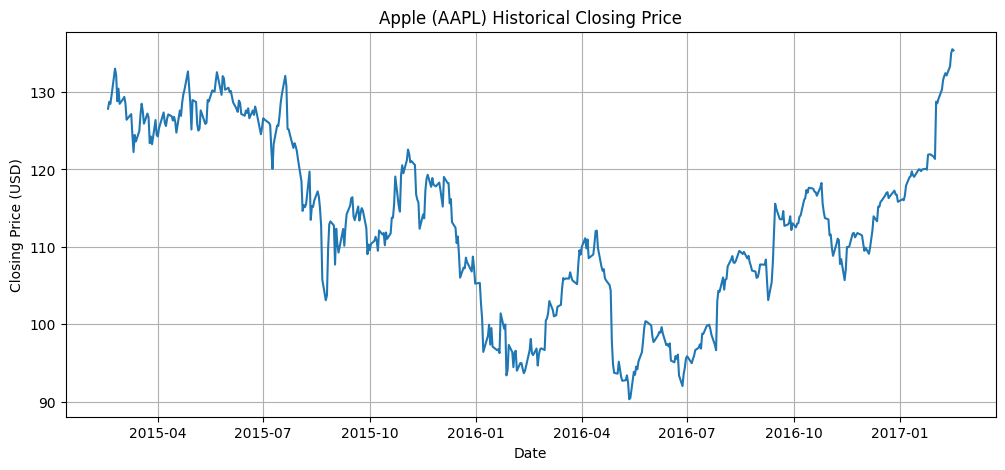

In [5]:
# Plot Apple's historical closing price

plt.figure(figsize=(12, 5))

plt.plot(data["Date"], data["AAPL.Close"])

plt.title("Apple (AAPL) Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.grid(True)

plt.show()

In [6]:
# Select only the closing price for forecasting
close_data = data[["Date", "AAPL.Close"]].copy()
# Rename the column for simplicity
close_data.rename(columns={"AAPL.Close": "Close"}, inplace=True)
# Display the selected data
print("Selected data for forecasting:")
print(close_data.head())
print("\nNumber of observations:", len(close_data))

Selected data for forecasting:
        Date       Close
0 2015-02-17  127.830002
1 2015-02-18  128.720001
2 2015-02-19  128.449997
3 2015-02-20  129.500000
4 2015-02-23  133.000000

Number of observations: 506


In [7]:
# Extract closing price values as a NumPy array
prices = close_data["Close"].values.reshape(-1, 1)
# Create Min-Max scaler
scaler = MinMaxScaler(feature_range=(0, 1))
# Fit the scaler and transform the prices
scaled_prices = scaler.fit_transform(prices)
# Display original and scaled values
print("Original closing prices:")
print(prices[:5])
print("\nScaled closing prices:")
print(scaled_prices[:5])
print("\nScaled data range:")
print("Minimum:", scaled_prices.min())
print("Maximum:", scaled_prices.max())

Original closing prices:
[[127.830002]
 [128.720001]
 [128.449997]
 [129.5     ]
 [133.      ]]

Scaled closing prices:
[[0.8299758 ]
 [0.84967912]
 [0.84370161]
 [0.8669472 ]
 [0.94443225]]

Scaled data range:
Minimum: 0.0
Maximum: 1.0


In [8]:
# Define the training data size
train_size = int(len(scaled_prices) * 0.80)
# Split the data chronologically
train_data = scaled_prices[:train_size]
test_data = scaled_prices[train_size:]
print("Total observations :", len(scaled_prices))
print("Training observations:", len(train_data))
print("Testing observations :", len(test_data))
print("\nTraining data range:")
print("From:", close_data["Date"].iloc[0].date())
print("To  :", close_data["Date"].iloc[train_size - 1].date())
print("\nTesting data range:")
print("From:", close_data["Date"].iloc[train_size].date())
print("To  :", close_data["Date"].iloc[-1].date())

Total observations : 506
Training observations: 404
Testing observations : 102

Training data range:
From: 2015-02-17
To  : 2016-09-21

Testing data range:
From: 2016-09-22
To  : 2017-02-16


## Creating Time-Series Sequences

LSTM models require sequential input data. Therefore, instead of giving the model individual stock prices, we create fixed-length sequences called **time windows**.

For this assignment, we use a **60-day window**.

For example:

Input:
[Price₁, Price₂, Price₃, ..., Price₆₀]

Target:
Price₆₁

Then we move the window forward by one day:

Input:
[Price₂, Price₃, Price₄, ..., Price₆₁]

Target:
Price₆₂

This process continues throughout the dataset.

### Why 60 Days?

A 60-day window allows the LSTM to learn patterns from approximately two months of previous trading observations before predicting the next closing price.

The final LSTM input will have the shape:

**(samples, 60, 1)**

where:
- `samples` = number of training/testing sequences
- `60` = previous time steps used as input
- `1` = one feature (Closing Price)

In [9]:
# Number of previous time steps used to predict the next price
time_step = 60
def create_sequences(data, time_step):
  X = []
  y = []
  for i in range(len(data) - time_step):
      # Previous 60 prices as input
      X.append(data[i:i + time_step, 0])

      # Next price as target
      y.append(data[i + time_step, 0])

  return np.array(X), np.array(y)
# Create training sequences
X_train, y_train = create_sequences(train_data, time_step)
# Create testing sequences
X_test, y_test = create_sequences(test_data, time_step)
print("Before reshaping:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

Before reshaping:
X_train shape: (344, 60)
y_train shape: (344,)
X_test shape : (42, 60)
y_test shape : (42,)


In [10]:
# Reshape input data into 3D format required by LSTM
# Shape: (samples, time steps, features)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("After reshaping:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

After reshaping:
X_train shape: (344, 60, 1)
y_train shape: (344,)
X_test shape : (42, 60, 1)
y_test shape : (42,)


## LSTM Model Architecture
The model will contain the following layers:
1. **LSTM Layer 1**
   - 50 LSTM units
   - `return_sequences=True`
   - Processes the 60-day input sequence and passes the complete sequence to the next LSTM layer.

2. **Dropout Layer**
   - Dropout rate = 0.2
   - Randomly disables some neurons during training to reduce overfitting.

3. **LSTM Layer 2**
   - 50 LSTM units
   - `return_sequences=False`
   - Processes the sequence and returns the final learned representation.

4. **Dropout Layer**
   - Dropout rate = 0.2

5. **Dense Output Layer**
   - 1 neuron
   - Produces the predicted next closing price.

### Model Flow

Input (60 time steps × 1 feature)
↓
LSTM (50 units)
↓
Dropout (20%)
↓
LSTM (50 units)
↓
Dropout (20%)
↓
Dense (1 neuron)
↓
Predicted Closing Price

In [11]:
# Build the LSTM model
model = Sequential()
# First LSTM layer
model.add(LSTM(
  units=50,
  return_sequences=True,
  input_shape=(X_train.shape[1], X_train.shape[2])
))
# Dropout to reduce overfitting
model.add(Dropout(0.2))
# Second LSTM layer
model.add(LSTM(
  units=50,
  return_sequences=False
))
# Dropout to reduce overfitting
model.add(Dropout(0.2))
# Output layer
model.add(Dense(1))
# Display model architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Compile the LSTM model
model.compile(
  optimizer="adam",
  loss="mean_squared_error"
)

print("Model compiled successfully!")
print("Optimizer: Adam")
print("Loss Function: Mean Squared Error (MSE)")

Model compiled successfully!
Optimizer: Adam
Loss Function: Mean Squared Error (MSE)


In [13]:
# Train the LSTM model
history = model.fit(
  X_train,
  y_train,
  epochs=50,
  batch_size=32,
  validation_split=0.10,
  verbose=1
)

print("\nModel training completed!")

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss: 0.0591 - val_loss: 0.0057
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0212 - val_loss: 0.0114
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0148 - val_loss: 0.0052
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0111 - val_loss: 0.0093
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0107 - val_loss: 0.0066
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0105 - val_loss: 0.0096
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0095 - val_loss: 0.0073
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0092 - val_loss: 0.0072
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0088 - val_loss: 0.0063
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0090 - val_loss: 0.0054
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0083 - val_loss: 0.0069
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.

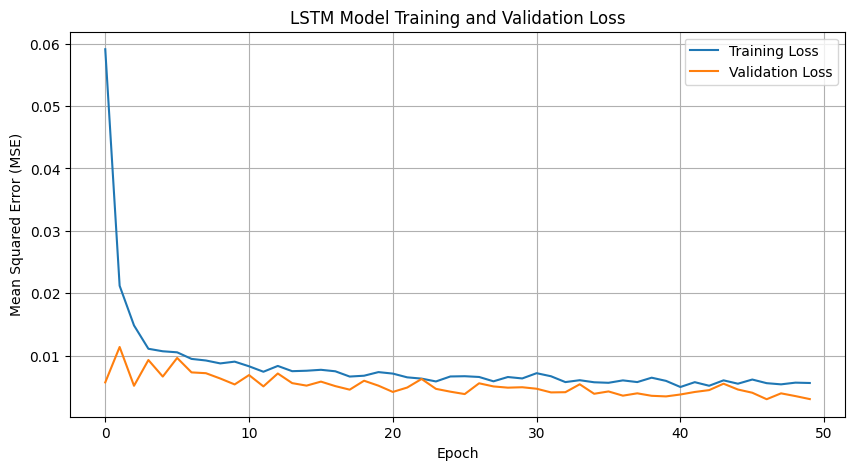

In [14]:
# Plot training and validation loss

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Model Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
# Generate predictions for the test data
predictions = model.predict(X_test)
# Display the shape of predictions
print("Predictions shape:", predictions.shape)
# Display first 5 scaled predictions
print("\nFirst 5 scaled predictions:")
print(predictions[:5])

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step
Predictions shape: (42, 1)

First 5 scaled predictions:
[[0.53275007]
 [0.5496295 ]
 [0.56505597]
 [0.57842886]
 [0.58905846]]


In [16]:
# Convert scaled predictions back to original stock-price values
predicted_prices = scaler.inverse_transform(predictions)
# Convert actual test values back to original stock-price values
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))
# Display first 10 actual and predicted prices
results = pd.DataFrame({
    "Actual Price": actual_prices.flatten(),
    "Predicted Price": predicted_prices.flatten()
})

print("First 10 Actual vs Predicted Prices:")
print(results.head(10).round(2))

First 10 Actual vs Predicted Prices:
   Actual Price  Predicted Price
0        115.97       114.400002
1        116.64       115.169998
2        116.95       115.860001
3        117.06       116.470001
4        116.29       116.949997
5        116.52       117.169998
6        117.26       117.260002
7        116.76       117.349998
8        116.73       117.349998
9        115.82       117.279999


In [17]:
# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(actual_prices, predicted_prices)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

print("LSTM Model Evaluation")
print("-" * 40)
print(f"Mean Absolute Error (MAE)  : ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

LSTM Model Evaluation
----------------------------------------
Mean Absolute Error (MAE)  : $1.37
Root Mean Squared Error (RMSE): $2.04


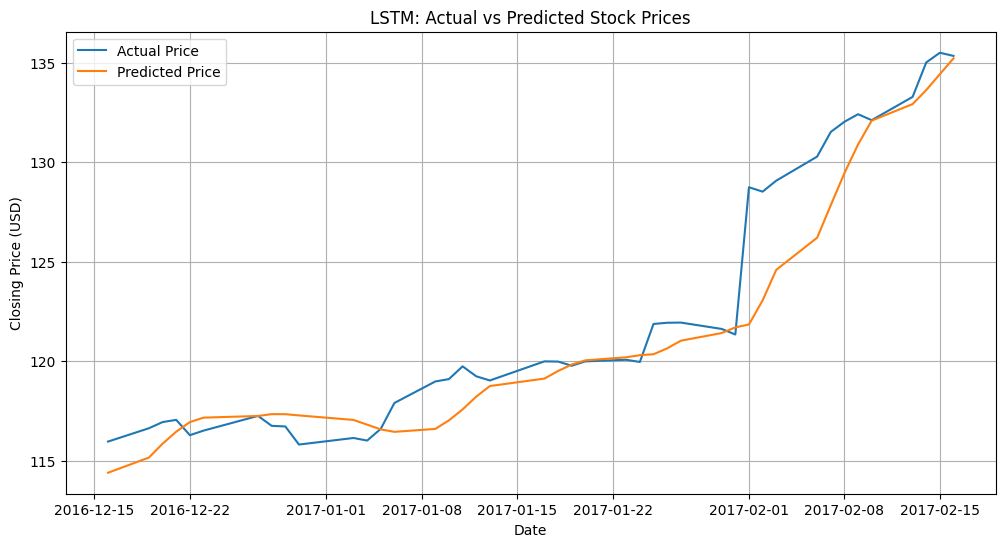

In [18]:
# Get the dates corresponding to the test predictions
test_dates = close_data["Date"].iloc[train_size + time_step:].reset_index(drop=True)

# Plot actual and predicted prices
plt.figure(figsize=(12, 6))

plt.plot(
    test_dates,
    actual_prices.flatten(),
    label="Actual Price"
)

plt.plot(
    test_dates,
    predicted_prices.flatten(),
    label="Predicted Price"
)

plt.title("LSTM: Actual vs Predicted Stock Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
from sklearn.metrics import r2_score
# Calculate R² score
r2 = r2_score(actual_prices, predicted_prices)
# Create final evaluation summary
evaluation_results = pd.DataFrame({
  "Metric": ["MAE", "RMSE", "R² Score"],
  "Value": [
    f"${mae:.2f}",
    f"${rmse:.2f}",
    f"{r2:.4f}"
  ]
})

print("FINAL LSTM MODEL EVALUATION")
print("=" * 40)
print(evaluation_results.to_string(index=False))

print("\nNumber of test predictions:", len(predicted_prices))

FINAL LSTM MODEL EVALUATION
  Metric  Value
     MAE  $1.37
    RMSE  $2.04
R² Score 0.8989

Number of test predictions: 42


# Results and Conclusion
## Results
The trained LSTM model was evaluated on unseen test data.

| Metric | Result |
|---|---:|
| Mean Absolute Error (MAE) | $1.37 |
| Root Mean Squared Error (RMSE) | $2.04 |
| R² Score | 0.8989 |

The model generated **42 test predictions** using a 60-day historical window.

An R² score of **0.8989** indicates that the model explains approximately **89.89% of the variation** in the test-set closing prices.

The Actual vs Predicted graph shows how closely the LSTM predictions follow the actual stock-price movement.

## Advantages

- LSTM is designed for sequential and time-series data.
- It can learn patterns from previous observations.
- The model can capture temporal dependencies better than a basic feed-forward neural network.
- Min-Max scaling helps provide normalized input to the neural network.
- MAE and RMSE provide easy-to-understand prediction error measurements.

## Limitations

- Stock prices are affected by many external factors that are not included in this model.
- Only historical closing prices are used as the input feature.
- The dataset contains a relatively small number of observations.
- LSTM predictions cannot guarantee the actual future movement of stock prices.
- The model may not perform equally well under sudden market changes.

## Conclusion

In this assignment, an LSTM-based deep learning model was developed for stock-price time-series forecasting. Historical Apple stock data was preprocessed, normalized, converted into 60-day sequences, and supplied to a two-layer LSTM network.

The model was trained using the Adam optimizer and Mean Squared Error loss function. After training, predictions were converted back to the original price scale and evaluated using MAE, RMSE, and R² Score.

The obtained results demonstrate that LSTM can learn useful temporal patterns from historical stock-price sequences and can be applied to time-series forecasting problems.